<a href="https://colab.research.google.com/github/aceiro/workflow-ml-gt-hc/blob/main/workflow_analisys_en_GT%2BHC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Program - MBA in Business Management and Artificial Intelligence

## Student - Erik Aceiro

## Context

This notebook is part of the final capstone project for the MBA in Business Management and Artificial Intelligence.

In the context of this research, *Grounded Theory* combined with *Hierarchical Clustering* (GT+HC) was used to identify recurring patterns in Creator Economy monetization funnels.


**Jaccard Similarity**


> Similarity between funnels was calculated using the Jaccard coefficient, which is widely used for comparing binary attributes and analyzing co-occurrence patterns (TAN; STEINBACH; KUMAR, 2006).

**Hierarchical Clustering**

> After computing similarity between cases, the Hierarchical Clustering technique was applied using the Average Linkage (UPGMA) method, allowing the identification of natural groupings among the analyzed funnels (MÜLLNER, 2011).

## References

> TAN, Pang-Ning; STEINBACH, Michael; KUMAR, Vipin. Introduction to Data Mining. Boston: Pearson Addison Wesley, 2006. Available at: https://www-users.cse.umn.edu/~kumar001/dmbook/index.php. Accessed on: Jun. 5, 2026.


> MÜLLNER, Daniel. Modern Hierarchical, Agglomerative Clustering Algorithms. arXiv:1109.2378, 2011. Available at: https://arxiv.org/abs/1109.2378. Accessed on: Jun. 5, 2026.
---



# Dummy Matrix

This notebook is a workflow for hierarchical clustering using Jaccard similarity and the UPGMA linkage method. We start by defining a dummy matrix, calculate the Jaccard distances between its rows, perform UPGMA clustering, and finally visualize the results with a dendrogram.

In [1]:
import pandas as pd

df = pd.DataFrame({
    "F01":[1,1,0,1,1,0,0,0,1,1],
    "F02":[1,1,0,1,1,1,0,0,1,1],
    "F03":[1,0,1,1,0,1,0,1,1,0],
    "F04":[1,1,0,1,0,1,0,0,1,0],
    "F05":[1,0,1,0,1,1,0,1,1,1],
    "F06":[1,1,0,0,1,0,1,0,0,1]
}).T

## Dummy Matrix

We define a dummy matrix, `df`, using pandas. Each row (F01 to F06) is a representative value for an infoproduct funnel in the creator technology domain, and the columns represent different characteristics (or features). The values (0 or 1) indicate the presence or absence of a specific attribute for each characteristic. This matrix will be used to calculate similarities between these characteristics.

# Jaccard Similarity

## Jaccard Similarity

Jaccard similarity is a statistic used to evaluate the similarity and diversity of sample sets. It is defined as the size of the intersection divided by the size of the union of the sample sets. Jaccard distance, which is 1 - Jaccard similarity, measures dissimilarity. We use `scipy.spatial.distance.pdist` with the `jaccard` metric to calculate pairwise Jaccard distances between the rows (characteristics) of our dummy matrix `df`. The result is stored in the `distances` array.

In [2]:
from scipy.spatial.distance import pdist

distances = pdist(
    df,
    metric='jaccard'
)

The `distances` array now contains the Jaccard distances between all unique pairs of characteristics in the `df` DataFrame.

# UPGMA

## UPGMA Linkage

UPGMA (Unweighted Pair Group Method with Arithmetic Mean) is a simple agglomerative hierarchical clustering method (bottom-up). It builds a hierarchical tree (dendrogram) by successively merging clusters. At each step, the two clusters with the smallest average distance among all members are merged. Here, `scipy.cluster.hierarchy.linkage` is used with the calculated Jaccard distances and the `average` method (which corresponds to UPGMA) to create the linkage matrix `Z`.

In [3]:
from scipy.cluster.hierarchy import linkage

Z = linkage(
    distances,
    method='average'
)

The `Z` matrix contains the hierarchical clustering encoded as a linkage matrix, which can then be used to plot a dendrogram.

# Dendrogram

## Dendrogram

A dendrogram is a tree-shaped diagram that records sequences of merges or splits. It visually represents the organization of the clusters produced by hierarchical clustering. Each 'leaf' in the dendrogram represents an individual data point (in our case, an example of an infoproduct funnel from F01 to F06), and the branches represent clusters. The branch height represents the distance at which clusters were merged. We use `scipy.cluster.hierarchy.dendrogram` to plot the dendrogram using the `Z` linkage matrix and label the leaves with the names of our characteristics (`df.index.tolist()`).

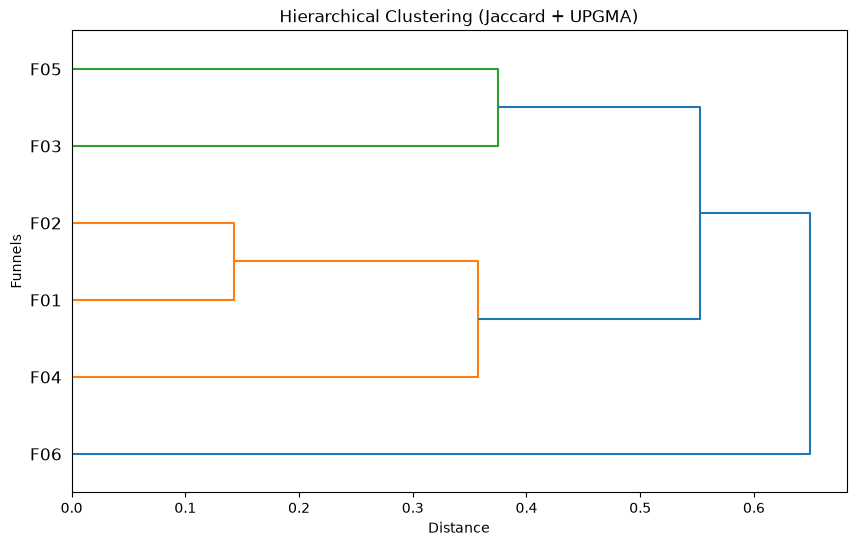

In [4]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(10,6))

dendrogram(
    Z,
    labels=df.index.tolist(),
    orientation='right' # Flips the view so the labels appear on the Y axis
)

plt.title("Hierarchical Clustering (Jaccard + UPGMA)")
plt.xlabel("Distance") # The X axis now represents distance
plt.ylabel("Funnels") # The Y axis now represents the funnels
plt.show()

## How dendrogram distance is calculated

Distance in the dendrogram represents the **dissimilarity** between the 'funnels' (in this case, F01 to F06) or between groups of funnels. This distance is calculated in two main steps:

1.  **Calculating Jaccard Distance between pairs of funnels**: First, we calculate the *Jaccard distance* between each individual pair of funnels (for example, F01 and F02, F01 and F03, etc.).
    *   **Jaccard Distance**: This is a measure of dissimilarity based on the comparison of binary attributes (0s and 1s). It is calculated as `1 - Jaccard Similarity`. Jaccard Similarity is the ratio between the number of shared attributes (intersection) and the total number of attributes (union) between two funnels. The greater the Jaccard distance, the less similar the funnels are.

2.  **Calculating Distance between Clusters (UPGMA)**: As hierarchical clustering progresses and the individual funnels begin to form clusters (groups), we need a way to measure the distance between these newly formed clusters.
    *   **UPGMA (Unweighted Pair Group Method with Arithmetic Mean)**: This method calculates the distance between two clusters as the *average of the Jaccard distances across all possible combinations of elements from one cluster with all elements from the other cluster*. In other words, it takes all previously calculated Jaccard distances between the members of the two clusters and computes their average.

In the dendrogram, the **height** at which two funnels or two clusters join indicates the distance (calculated by the UPGMA method from the original Jaccard distances) at which they were grouped. The greater the height, the greater the dissimilarity between the elements or clusters at that merge point.